# Credit Risk & Loan Approval Analytics
## Data Audit

In [15]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [9]:
df = pd.read_csv('../data/loan_data.csv')
print(df.shape)  #cols,rows

(614, 13)


In [10]:
df.dtypes #to check data types

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [11]:
df.head(10) #to view the first 10 rows of the dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [12]:
# Checking for duplicates
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicated Loan_IDs:', df['Loan_ID'].duplicated().sum())

Fully duplicated rows: 0
Duplicated Loan_IDs: 0


In [13]:
# Checking for missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
# Unique values in categorical columns
for col in df.select_dtypes(include='object').columns:
    print(col, '->', df[col].unique())

Loan_ID -> <StringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str
Gender -> <StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
Married -> <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Dependents -> <StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
Education -> <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
Self_Employed -> <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Property_Area -> <StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str
Loan_Status -> <StringArray>
['Y', 'N']
Length: 2, dtype: str


In [17]:
df.describe() #To check the summary statistics of the dataset

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [18]:
# Checking the distribution of the target variable
print(df['Loan_Status'].value_counts())
print()
print(df['Loan_Status'].value_counts(normalize=True).round(4) * 100)

Loan_Status
Y    422
N    192
Name: count, dtype: int64

Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


**Target split:** roughly 69% Approved / 31% Rejected. There is a *mild* imbalance but  not extreme.

## Data Cleaning

In [19]:
df_clean = df.copy()

#### a. `Gender`, `Married`, `Self_Employed` - categorical, small number of missing values

**Reasoning:** these each have relatively few missing values (13, 3, 32 out of 614) and no natural numeric substitute. For a low missing rate categorical column with no obvious relationship driving the missingness, filling with the **mode**  is a reasonable, low-risk choice.

In [20]:
for col in ['Gender', 'Married', 'Self_Employed']:
    mode_val = df_clean[col].mode()[0]
    print(f"{col}: filling {df_clean[col].isnull().sum()} missing with mode = '{mode_val}'")
    df_clean[col] = df_clean[col].fillna(mode_val)

Gender: filling 13 missing with mode = 'Male'
Married: filling 3 missing with mode = 'Yes'
Self_Employed: filling 32 missing with mode = 'No'


#### b. `Dependents` 

1. Filling missing values with the mode 
2. Converting `'3+'` to `3` so the column becomes a usable integer 

In [21]:
print('Dependents missing:', df_clean['Dependents'].isnull().sum())
mode_dep = df_clean['Dependents'].mode()[0]
df_clean['Dependents'] = df_clean['Dependents'].fillna(mode_dep)

df_clean['Dependents'] = df_clean['Dependents'].replace('3+', '3').astype(int)
df_clean['Dependents'].value_counts().sort_index()

Dependents missing: 15


Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64

#### c. `LoanAmount` 

**Reasoning:** `LoanAmount` is likely right-skewed.The **median** is robust to that skew, so it's a safer fill value than the mean.

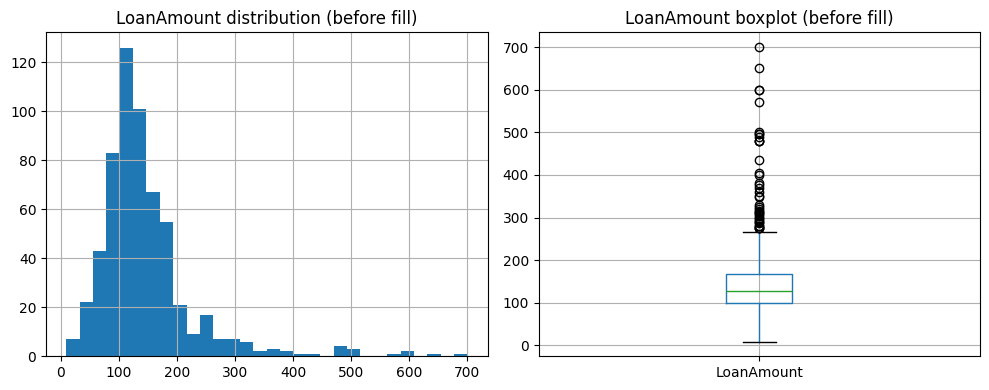

Mean: 146.4
Median: 128.0


In [23]:
# To fill the missing values in the 'LoanAmount' column, we can use the median value of the column. The median is a better measure of central tendency for skewed distributions, which is often the case with financial data like loan amounts.
# Checking the distribution of the 'LoanAmount' column before filling missing values
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_clean['LoanAmount'].hist(bins=30, ax=ax[0])
ax[0].set_title('LoanAmount distribution (before fill)')
df_clean.boxplot(column='LoanAmount', ax=ax[1])
ax[1].set_title('LoanAmount boxplot (before fill)')
plt.tight_layout()
plt.show()

print('Mean:', df_clean['LoanAmount'].mean().round(1))
print('Median:', df_clean['LoanAmount'].median())

In [24]:
median_loan = df_clean['LoanAmount'].median()
print(f"Filling {df_clean['LoanAmount'].isnull().sum()} missing LoanAmount values with median = {median_loan}")
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(median_loan)

Filling 22 missing LoanAmount values with median = 128.0


#### d. `Loan_Amount_Term`

In [26]:
# Checking the distribution of the 'Loan_Amount_Term' column before filling missing values
print(df_clean['Loan_Amount_Term'].value_counts())
mode_term = df_clean['Loan_Amount_Term'].mode()[0] # Finding the mode of the 'Loan_Amount_Term' column
print(f"\nFilling {df_clean['Loan_Amount_Term'].isnull().sum()} missing values with mode = {mode_term}")
df_clean['Loan_Amount_Term'] = df_clean['Loan_Amount_Term'].fillna(mode_term)

Loan_Amount_Term
360.0    526
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

Filling 0 missing values with mode = 360.0
